# GreenSurge

An efficient additive model for predicting storm surge induced by tropical cyclones [Pérez-Diaz et al., 2024](https://www.sciencedirect.com/science/article/abs/pii/S0378383924002394)

In [1]:
site = "Tonga"

path_grd_forz = f"inputs/mesh_{site}_Viento_adcirc.grd"
path_grd_calc = f"inputs/mesh_{site}_Calc_adcirc.grd"
netcdf_mesh_path = f"templates/mesh_{site}_net.nc"

In [2]:
from bluemath_tk.additive.greensurge import adcirc2DFlowFM

adcirc2DFlowFM(Path_grd=path_grd_calc, netcdf_path=netcdf_mesh_path)

## Parameterization of the library

In [3]:
from datetime import datetime

wind_speed = 40
direction_step = 45
simulation_duration_hours = 6
simulation_time_step_hours = 1 / 4
forcing_time_step = simulation_time_step_hours

reference_date = [2022, 1, 1, 0, 0, 0]
reference_date_dt = datetime(*reference_date)

Eddy = 10
Chezy = 70

# Wind drag coefficients and thresholds
wind_equilibrium_code = 2
drag_coefficients = [0.00063, 0.00723, 0.00723]
velocity_thresholds = [0, 100, 100]

In [4]:
import os

from bluemath_tk.additive.greensurge import build_greensurge_infos_dataset

setup_info_ds = build_greensurge_infos_dataset(
    path_grd_calc=path_grd_calc,
    path_grd_forz=path_grd_forz,
    site=site,
    wind_speed=wind_speed,
    direction_step=direction_step,
    simulation_duration_hours=simulation_duration_hours,
    simulation_time_step_hours=simulation_time_step_hours,
    forcing_time_step=forcing_time_step,
    reference_date_dt=reference_date_dt,
    Eddy=Eddy,
    Chezy=Chezy,
)

outputs_path = f"outputs/GreenSurge_{site}_info.nc"
if not os.path.exists("outputs"):
    os.makedirs("outputs")

setup_info_ds.attrs["source"] = outputs_path

setup_info_ds.to_netcdf(
    outputs_path,
    "w",
    "NETCDF3_CLASSIC",
)

setup_info_ds

<xarray.Dataset> Size: 388kB
Dimensions:                            (element_computation_index: 8657,
                                        triangle_forcing_nodes: 3,
                                        node_forcing_index: 15,
                                        element_forcing_index: 16,
                                        wind_direction_index: 8,
                                        time_forcing_index: 4,
                                        node_cumputation_index: 4553)
Coordinates:
  * element_computation_index          (element_computation_index) int64 69kB ...
  * node_forcing_index                 (node_forcing_index) int64 120B 0 ... 14
  * element_forcing_index              (element_forcing_index) int64 128B 0 ....
  * wind_direction_index               (wind_direction_index) int64 64B 0 ... 7
  * time_forcing_index                 (time_forcing_index) float64 32B 0.0 ....
  * node_cumputation_index             (node_cumputation_index) int64 36kB 0 ...
    node_computation_longitude         (node_cumputation_index) float64 36kB ...
    node_computation_latitude          (node_cumputation_index) float64 36kB ...
    triangle_nodes                     (triangle_forcing_nodes) int64 24B 0 1 2
Dimensions without coordinates: triangle_forcing_nodes
Data variables: (12/14)
    triangle_computation_connectivity  (element_computation_index, triangle_forcing_nodes) int64 208kB ...
    node_forcing_longitude             (node_forcing_index) float64 120B -175...
    node_forcing_latitude              (node_forcing_index) float64 120B -21....
    triangle_forcing_connectivity      (element_forcing_index, triangle_forcing_nodes) int64 384B ...
    wind_directions                    (wind_direction_index) int64 64B 0 ......
    total_elements                     int64 8B 16
    ...                                 ...
    wind_speed                         int64 8B 40
    location_name                      <U5 20B 'Tonga'
    eddy_viscosity                     int64 8B 10
    chezy_coefficient                  int64 8B 70
    reference_date                     <U19 76B '2022-01-01 00:00:00'
    forcing_time_step                  float64 8B 0.25
Attributes:
    title:        Hybrid Simulation Input Dataset
    description:  Structured dataset containing simulation parameters for hyb...
    created:      2025-10-19 21:42:17
    institution:  GeoOcean
    model:        GreenSurge
    source:       outputs/GreenSurge_Tonga_info.nc

## Mesh Setup

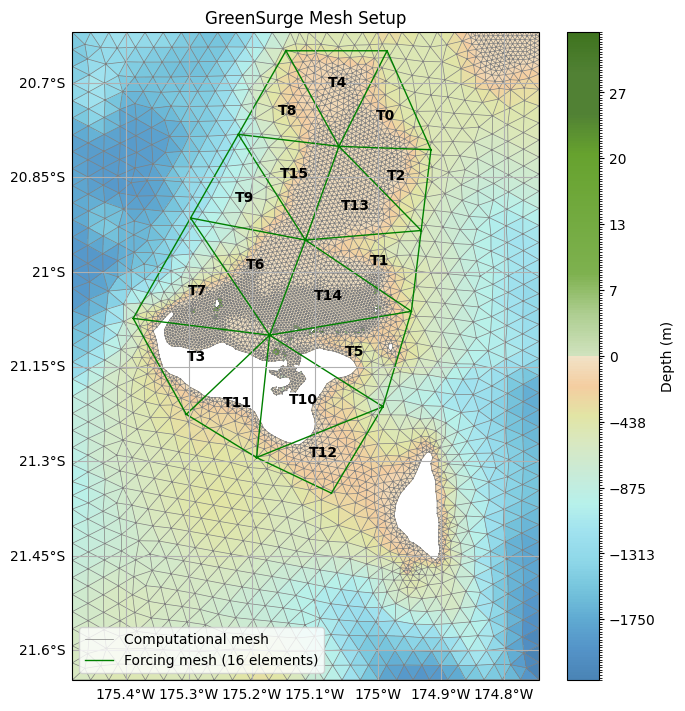

In [5]:
from bluemath_tk.additive.greensurge import plot_greensurge_setup_with_raster

plot_greensurge_setup_with_raster(
    simulation_dataset=setup_info_ds, path_grd_calc=path_grd_calc, figsize=(7, 7)
)

In [6]:
from datetime import datetime, timedelta

import numpy as np

wind_direction_indices = setup_info_ds.wind_direction_index.values
element_indices = setup_info_ds.element_forcing_index.values
num_directions = len(wind_direction_indices)
num_elements = len(element_indices)

direction_grid, element_grid = np.meshgrid(wind_direction_indices, element_indices)
flattened_directions = direction_grid.flatten()
flattened_elements = element_grid.flatten()

reference_datetime = datetime.strptime(
    str(setup_info_ds.reference_date.values), "%Y-%m-%d %H:%M:%S"
)
simulation_end_datetime = reference_datetime + timedelta(
    hours=int(setup_info_ds.simulation_duration_hours.values)
)

# Parameters for the metamodel (per element and direction)
metamodel_parameters = {
    "direction": flattened_directions,
    "tesela": flattened_elements,
}

# Fixed simulation parameters
fixed_parameters = {
    "MapInterval": 3600 * setup_info_ds.time_step_hours.values,
    "RefDate": reference_datetime.strftime("%Y%m%d"),
    "StartDateTime": reference_datetime.strftime("%Y%m%d%H%M%S"),
    "StopDateTime": simulation_end_datetime.strftime("%Y%m%d%H%M%S"),
    "CDa": drag_coefficients[0],
    "CDb": drag_coefficients[1],
    "CDc": drag_coefficients[2],
    "VCDa": velocity_thresholds[0],
    "VCDb": velocity_thresholds[1],
    "VCDc": velocity_thresholds[2],
    "Wind_eq": wind_equilibrium_code,
    "eddy": setup_info_ds.eddy_viscosity.values,
    "chezy": setup_info_ds.chezy_coefficient.values,
    "NetFile": f"mesh_{setup_info_ds.location_name.values}_net.nc",
    "W2Map": 1,
    "dt_forz": setup_info_ds.forcing_time_step.values,
    "ds_GFD_info": setup_info_ds,
    "wind_magnitude": setup_info_ds.wind_speed.values,
    "simul_time": setup_info_ds.simulation_duration_hours.values,
    "dir_steps": num_directions,
    "forcing_type": "ASCII",
}

## Delft3D Modelling

In [7]:
from bluemath_tk.wrappers.delft3d.delft3d_wrapper import GreenSurgeModelWrapper

delft3d_wrapper = GreenSurgeModelWrapper(
    templates_dir="templates",
    metamodel_parameters=metamodel_parameters,
    fixed_parameters=fixed_parameters,
    output_dir="TONGA_CASES",
)

2025-10-19 21:42:24,213 - GreenSurgeModelWrapper - WARNING - Parameter direction is not in the default_parameters
2025-10-19 21:42:24,214 - GreenSurgeModelWrapper - WARNING - Parameter tesela is not in the default_parameters


In [8]:
delft3d_wrapper.build_cases(
    cases_name_format=lambda ctx: f"GF_T_{ctx.get('tesela')}_D_{ctx.get('direction')}",
)

In [9]:
delft3d_wrapper.run_cases_in_background(launcher="sh launchDelft3d.sh", num_workers=2)

In [27]:
delft3d_wrapper.monitor_cases(
    dia_file_name="dflowfmoutput/GreenSurge_GFDcase.dia", value_counts="simple"
)

Status  
FINISHED    128
Name: count, dtype: int64

In [28]:
delft3d_wrapper.postprocess_cases(
    ds_GFD_info=setup_info_ds,
    parallel=False,
)